In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [16]:
dataset = pd.read_csv("Mall_Customers.csv")
dataset

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [17]:
#we just need the Annaul income and Spending Score as Input from the dataset.
X = dataset.iloc[:,[3,4]].values
#if we need some specific rows, then we need to mention that. (e.g) X = dataset.iloc[1:5,[3,4]].values . it means rowas 1 to 5
#[1:5,3:4] this also will work. if we use ',' then it is exact column number. if we use ':', then it is range of rows & columns. always starts from 0 for rows & columns
#".values" is important to store the values as list in array. if we miss this, it will be just stored as DataFrame/Table.

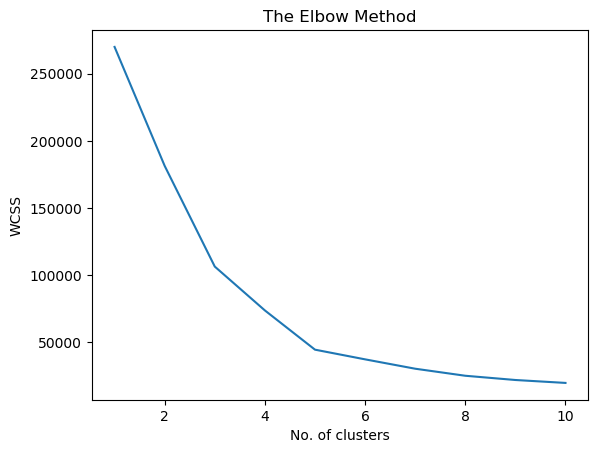

In [18]:
from sklearn.cluster import KMeans
list1 = []
for i in range (1, 11):#create 11 clusters 
    kmeans_cluster = KMeans(n_clusters = i, init = 'k-means++', random_state = 42)
    kmeans_cluster.fit(X)#creating model for each i value
    list1.append(kmeans_cluster.inertia_ ) # this .interia_ is one of the attributes of Kmeans algorithm
#To polt the graph
plt.plot(range(1,11), list1) # X axis is no. of clusters 1 to 11, Y axis is interia for respective no. of cluster from the list 1
#to name the graph
plt.title("The Elbow Method")
#To name X & Y axis
plt.xlabel("No. of clusters")
plt.ylabel("WCSS")#intertia
plt.show()

In [19]:
#The least interuption in the elbow graph is no.of clusters = 5
#now we can create create cluster group for 5 number of cluster.
from sklearn.cluster import KMeans
kmeans_cluster = KMeans(n_clusters=5, init="k-means++", random_state=42)
y_kmeans = kmeans_cluster.fit_predict(X)#in cluster, the function id fit_predict
y_kmeans


array([2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3,
       2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 0,
       2, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 1, 4, 0, 4, 1, 4, 1, 4,
       0, 4, 1, 4, 1, 4, 1, 4, 1, 4, 0, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4,
       1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4,
       1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4,
       1, 4])

In [20]:
supervised = pd.DataFrame(dataset) # saving the dataset in new variable. supervised = dataset. this also will work
supervised["Cluster_Group"]=y_kmeans # adding new column "Cluster_Group", populate y_means value in col. Cluster_Group
supervised

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster_Group
0,1,Male,19,15,39,2
1,2,Male,21,15,81,3
2,3,Female,20,16,6,2
3,4,Female,23,16,77,3
4,5,Female,31,17,40,2
...,...,...,...,...,...,...
195,196,Female,35,120,79,4
196,197,Female,45,126,28,1
197,198,Male,32,126,74,4
198,199,Male,32,137,18,1


In [21]:
#save the 'supervised' table in csv format
supervised.to_csv("KMeans cluster.csv", index=False)
#if index is True, it will again create a serial/index number

In [22]:
#if you want to see what are the classes or inbuilt function in a library
dir(KMeans)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_check_feature_names',
 '_check_mkl_vcomp',
 '_check_n_features',
 '_check_params',
 '_check_test_data',
 '_estimator_type',
 '_get_param_names',
 '_get_tags',
 '_init_centroids',
 '_more_tags',
 '_repr_html_',
 '_repr_html_inner',
 '_repr_mimebundle_',
 '_transform',
 '_validate_center_shape',
 '_validate_data',
 'fit',
 'fit_predict',
 'fit_transform',
 'get_params',
 'predict',
 'score',
 'set_params',
 'transform']

In [23]:
#if you want to see the centroid points for each cluster group.
kmeans_cluster.cluster_centers_

array([[55.2962963 , 49.51851852],
       [88.2       , 17.11428571],
       [26.30434783, 20.91304348],
       [25.72727273, 79.36363636],
       [86.53846154, 82.12820513]])

In [24]:
y_kmeans

array([2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3,
       2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 0,
       2, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 1, 4, 0, 4, 1, 4, 1, 4,
       0, 4, 1, 4, 1, 4, 1, 4, 1, 4, 0, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4,
       1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4,
       1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4,
       1, 4])

C:\Anaconda3\envs\aiml\lib\site-packages\seaborn\regression.py:582: UserWarning: legend_out is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


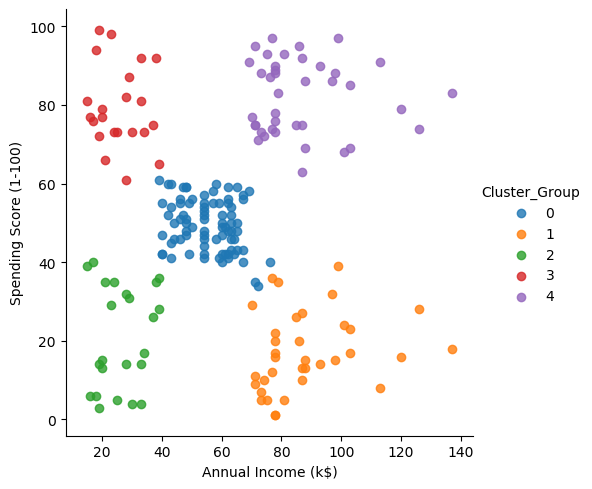

In [25]:
#This is just to see the clusters in graph
import seaborn as sns#seaborn library is used for graphyical purpose
facet = sns.lmplot(data=supervised, x=supervised.columns[3] , y=supervised.columns[4], hue = supervised.columns[5], fit_reg = False, legend=True, legend_out = True)
#Supervised is the variaable where we have stored our data. (always starts with 0)
#X axis is 3rd column name, Y axis is 4th column name
#"hue" is used to differentiate the cluster groups with colors. Cluster group is in 5th column in data
#we don't use regression here. so fit_reg= False
#legend for color explanation.if needed it should be true
#legend out is for showing the legend out of graph not inside the graph. if needed it should be true

In [26]:
from sklearn.metrics import silhouette_score
score = silhouette_score(X, y_kmeans)
print("Silhouette Score: ", score)

Silhouette Score:  0.553931997444648
